### Mall customers clusterization
#### K-Means algorithm

In [ ]:
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import davies_bouldin_score, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from kneed import KneeLocator
import seaborn as sns 
sns.set_theme()

In [2]:
mall_df = pd.read_csv("Mall_Customers.csv")

print(mall_df.describe())
print(mall_df.info())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-

In [3]:
one_hot_enc = OneHotEncoder(drop="first", sparse_output=False   )
gender_encoded = one_hot_enc.fit_transform(mall_df[["Gender"]])
gender_encoded_df = pd.DataFrame(gender_encoded, columns=one_hot_enc.get_feature_names_out(["Gender"]))

mall_df = mall_df.drop(labels=["Gender"], axis=1)
mall_df = mall_df.reset_index(drop=True)
mall_df = pd.concat([mall_df, gender_encoded_df], axis=1)

In [4]:
X = mall_df[["Annual Income (k$)", "Spending Score (1-100)"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
k_means = KMeans(n_clusters=5, n_init=10, random_state=42)
mall_df["Cluster"] = k_means.fit_predict(X_scaled)
print(f"WCV = {k_means.inertia_}")

WCV = 65.56840815571681


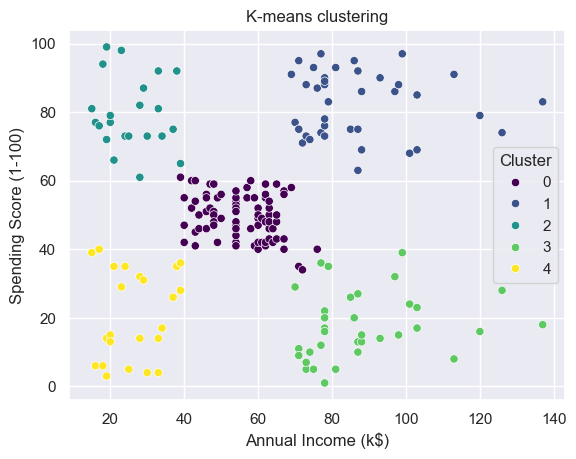

In [6]:
sns.scatterplot(mall_df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster", palette="viridis")
plt.title("K-means clustering")
plt.show()

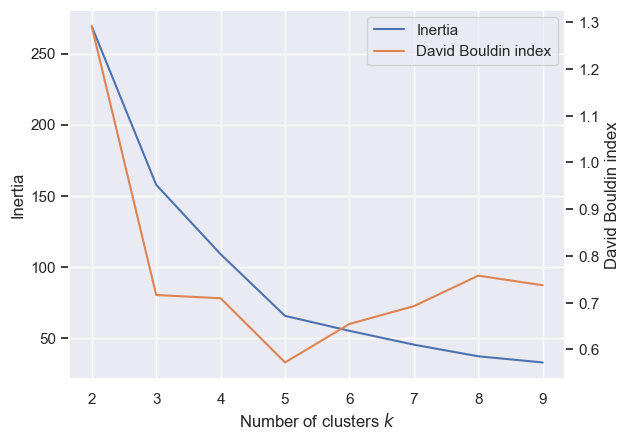

In [7]:
# Finding optimal clusters amount
inertias, dbs, ss = [], [], []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    dbs.append(davies_bouldin_score(X_scaled, kmeans.labels_))
    ss.append(silhouette_score(X_scaled, kmeans.labels_))


fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
l1, = ax1.plot(range(2, 10), inertias, color='C0', label='Inertia')
l2, = ax2.plot(range(2, 10), dbs, color='C1', label='David Bouldin index')
ax1.set_xlabel("Number of clusters $k$")
ax1.set_ylabel("Inertia")
ax2.set_ylabel("David Bouldin index")
ax2.grid(False)
ax1.legend(handles=[l1, l2], loc="upper right")
plt.show()

In [8]:
kl = KneeLocator(range(2, 10), inertias, curve="convex", direction="decreasing")
print(f"Optimal number of clusters: {kl.elbow}")

Optimal number of clusters: 5


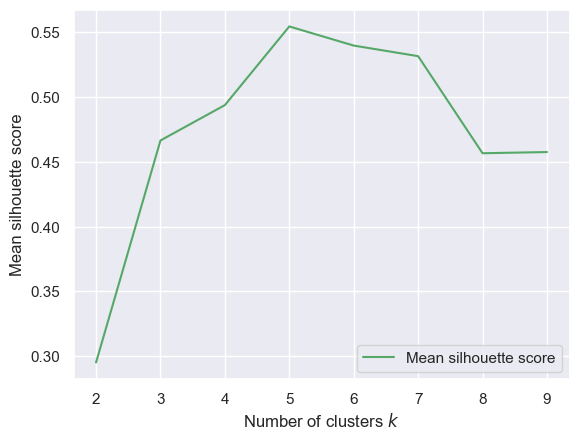

In [9]:
plt.plot(range(2, 10), ss, color="C2", label="Mean silhouette score")
plt.xlabel("Number of clusters $k$")
plt.ylabel("Mean silhouette score")
plt.legend(loc="lower right")
plt.show()

/var/folders/8m/2bmbch8140x5z1y896yqv01r0000gn/T/ipykernel_12914/2997243704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=k_means.labels_, y=mall_df["Annual Income (k$)"], palette="Set2")


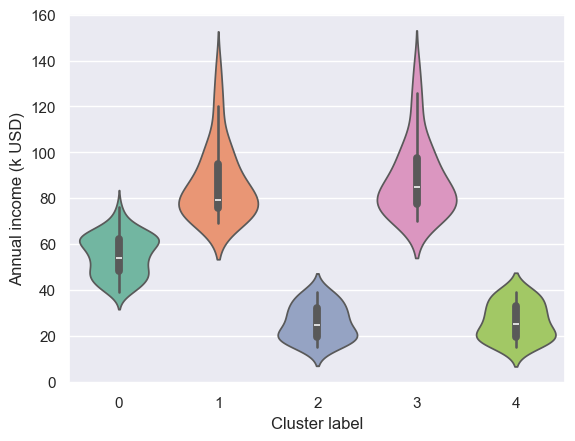

In [10]:
# Using violin plots to display clustering data analysis
sns.violinplot(x=k_means.labels_, y=mall_df["Annual Income (k$)"], palette="Set2")
plt.xlabel("Cluster label")
plt.ylabel("Annual income (k USD)")
plt.show()